In [1]:
#import the basic libraries
import numpy as np
import pandas as pd

In [2]:
pd.options.display.max_rows= None

In [3]:
#import warning
import warnings
warnings.filterwarnings('ignore')

In [4]:
#load all the datasets we have created previously

load_data_inputs_train=pd.read_csv('loan_data_inputs_train.csv',index_col=0)
load_data_targets_train=pd.read_csv('loan_data_targets_train.csv',index_col=0,header=None)
load_data_inputs_test=pd.read_csv('loan_data_inputs_test.csv',index_col=0)
load_data_targets_test=pd.read_csv('loan_data_targets_test.csv',index_col=0, header=None)

In [5]:
#print the head of load_data_targets
load_data_targets_train.head()

,1
0,
NaN,good_bad
427211.0,1
206088.0,1
136020.0,1
412305.0,0


In [6]:
#drop the first row as it is string
load_data_targets_train=load_data_targets_train.drop(load_data_targets_train.index[0])

In [7]:
#view the shape of load_data_inputs_train dataframe
load_data_inputs_train.shape

(373028, 334)

In [8]:
#view the shape of load_data_targets_train dataframe
load_data_targets_train.shape

(373028, 1)

In [9]:
#create a new column outcome(0 or 1) in load_data_inputs_train
load_data_inputs_train['outcome'] = load_data_targets_train

In [11]:
#check the value_counts of outcome
load_data_inputs_train['outcome'].value_counts()

outcome
1    233438
1     98812
0     28705
0     12073
Name: count, dtype: int64

In [12]:
#type cast outcome as integer
load_data_inputs_train['outcome'] = pd.to_numeric(load_data_inputs_train['outcome'])

In [17]:
#check the value_counts of outcome
load_data_inputs_train['outcome'].value_counts()

outcome
1    332250
0     40778
Name: count, dtype: int64

In [18]:
#check the head of load_data_inputs_train
load_data_inputs_train.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,dti:25-30,dti:30-35,dti:35-40,dti:>40,mths_since_last_record:Missing,mths_since_last_record:0-90,mths_since_last_record:90-120,mths_since_last_record:120-127,mths_since_last_record:>=127,outcome
427211,427211,12796369,14818505,24000,24000,24000.0,36 months,8.90,762.08,A,...,0,0,0,0,1,0,0,0,0,1
206088,206088,1439740,1691948,10000,10000,10000.0,36 months,14.33,343.39,C,...,0,0,0,0,1,0,0,0,0,1
136020,136020,5214749,6556909,20425,20425,20425.0,36 months,8.90,648.56,A,...,0,0,0,0,1,0,0,0,0,1
412305,412305,13827698,15890016,17200,17200,17200.0,36 months,16.59,609.73,D,...,0,0,0,0,1,0,0,0,0,0
36159,36159,422455,496525,8400,8400,7450.0,36 months,12.84,282.40,C,...,0,0,0,0,1,0,0,0,0,0


In [19]:
#Take only the default cases where outcome = 0 
load_data_defaults =load_data_inputs_train[load_data_inputs_train['outcome']==0]                                                                                 
#taking only defaults

In [20]:
#check the head of load_data_defaults
load_data_defaults.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,dti:25-30,dti:30-35,dti:35-40,dti:>40,mths_since_last_record:Missing,mths_since_last_record:0-90,mths_since_last_record:90-120,mths_since_last_record:120-127,mths_since_last_record:>=127,outcome
412305,412305,13827698,15890016,17200,17200,17200.0,36 months,16.59,609.73,D,...,0,0,0,0,1,0,0,0,0,0
36159,36159,422455,496525,8400,8400,7450.0,36 months,12.84,282.40,C,...,0,0,0,0,1,0,0,0,0,0
454638,454638,10494891,12367014,20000,20000,20000.0,36 months,11.99,664.20,B,...,0,0,0,0,1,0,0,0,0,0
222888,222888,1197171,1438165,8500,8500,8500.0,36 months,8.90,269.91,A,...,0,0,0,0,1,0,0,0,0,0
377139,377139,17523141,19645687,4850,4850,4850.0,36 months,16.99,172.90,D,...,1,0,0,0,1,0,0,0,0,0


In [21]:
#check for null values in every column
load_data_defaults.isnull().sum()

Unnamed: 0                                                             0
id                                                                     0
member_id                                                              0
loan_amnt                                                              0
funded_amnt                                                            0
funded_amnt_inv                                                        0
term                                                                   0
int_rate                                                               0
installment                                                            0
grade                                                                  0
sub_grade                                                              0
emp_title                                                           3046
emp_length                                                          2215
home_ownership                                     

In [22]:
#select only the important features we have created before in preprocessing steps and create a list of those features
feature_selection=[
'grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NC_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Verified',
'verification_status:Source Verified',
'verification_status:Not Verified',
    'purpose:educ_sm_b_wedd_ren_en_mov_house',
    'purpose:small_business',
    'purpose:educational',
    'purpose:renewable_energy',
    'purpose:moving',
    'purpose:house',
    'purpose:other',
    'purpose:medical',
    'purpose:wedding',
    'purpose:vacation',
    'purpose:debt_consolidation',
    'purpose:home_improvement',
    'purpose:major_purchase',
    'purpose:car',
    'purpose:credit_card',
    'initial_list_status:f',
    'initial_list_status:w',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mths_since_issued_date:<120', 'mths_since_issued_date:120-124', 'mths_since_issued_date:124-128',
'mths_since_issued_date:128-135', 'mths_since_issued_date:135-140', 'mths_since_issued_date:140-145', 
'mths_since_issued_date:145-165','mths_since_issued_date:>165',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:20.281',
    'mths_since_earliest_cr_line:<140',
    'mths_since_earliest_cr_line:140-239',
    'mths_since_earliest_cr_line:240-339',
    'mths_since_earliest_cr_line:340-439',
    'mths_since_earliest_cr_line:440-539',
    'mths_since_earliest_cr_line:540-600',
    'mths_since_earliest_cr_line:>600',
    'delinq_2yrs:0',
    'delinq_2yrs:0-3',
    'delinq_2yrs:3-7',
    'delinq_2yrs:7-9',
    'delinq_2yrs:9-11',
    'delinq_2yrs:11-12',
    'delinq_2yrs:12-18',
    'delinq_2yrs:>18',
    'inq_last_6mths:0', 'inq_last_6mths:1-2', 'inq_last_6mths:4-6', 'inq_last_6mths:7-9', 'inq_last_6mths:10-11', 
    'inq_last_6mths:12-13', 'inq_last_6mths:14-17', 'inq_last_6mths:18',
    'open_acc:=0', 'open_acc:1-3', 'open_acc:4-12', 'open_acc:13-17', 'open_acc:18-22', 'open_acc:23-25', 'open_acc:26-30', 'open_acc:>31',
    'pub_rec:0-2', 'pub_rec:3-4', 'pub_rec:>5',
    'total_acc:<0',
    'total_acc:0-4',
    'total_acc:4-62',
    'total_acc:62-72',
    'total_acc:72-85',
    'total_acc:>85',
    'acc_now_delinq:=0', 'acc_now_delinq:>=1',
'annual_inc:<20k',
'annual_inc:20k-30k',
'annual_inc:30k-40k',
'annual_inc:40k-50k',
'annual_inc:50k-60k',
'annual_inc:60k-70k',
'annual_inc:70k-80k',
'annual_inc:80k-90k',
'annual_inc:90k-100k',
'annual_inc:100k-120k',
'annual_inc:120k-140k',
'annual_inc:>140k',
'total_rev_hi_lim:<=5k',
'total_rev_hi_lim:5k_10k',
'total_rev_hi_lim:10k_20k',
'total_rev_hi_lim:20k_30k',
'total_rev_hi_lim:30k_40k',
'total_rev_hi_lim:40k_50k',
'total_rev_hi_lim:50k_65k',
'total_rev_hi_lim:65k_80k',
'total_rev_hi_lim:>80k',
'dti:<5',
'dti:5-10',
'dti:10-15',
'dti:15-20',
'dti:20-25',
'dti:25-30',
'dti:30-35',
'dti:35-40',
'dti:>40',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-90',
'mths_since_last_record:90-120',
'mths_since_last_record:120-127',
'mths_since_last_record:>=127','loan_amnt','funded_amnt','int_rate','installment','recoveries','total_rec_prncp']

In [23]:
#assign them into a inputs_train_with_ref_category with only those columns which are in the list(feature selection)
load_data_defaults = load_data_defaults.reindex(feature_selection, axis='columns')

In [24]:
#check for null values in load_data_defaults
load_data_defaults.isnull().sum()

grade:A                                    0
grade:B                                    0
grade:C                                    0
grade:D                                    0
grade:E                                    0
grade:F                                    0
grade:G                                    0
home_ownership:RENT_OTHER_NONE_ANY         0
home_ownership:OWN                         0
home_ownership:MORTGAGE                    0
addr_state:ND_NE_IA_NC_FL_HI_AL            0
addr_state:NM_VA                           0
addr_state:OK_TN_MO_LA_MD_NC               0
addr_state:UT_KY_AZ_NJ                     0
addr_state:AR_MI_PA_OH_MN                  0
addr_state:RI_MA_DE_SD_IN                  0
addr_state:GA_WA_OR                        0
addr_state:WI_MT                           0
addr_state:IL_CT                           0
addr_state:KS_SC_CO_VT_AK_MS               0
addr_state:WV_NH_WY_DC_ME_ID               0
verification_status:Verified               0
verificati

### Recovery Rate:
It is the recovered amount divided by the funded amount

In [25]:
#create a new column recovery_rate i.e. 'recoveries'/'funded_amnt'
load_data_defaults['recovery_rate'] = load_data_defaults['recoveries']/load_data_defaults['funded_amnt']

In [26]:
#check the statistics of recovery_rate
load_data_defaults['recovery_rate'].describe()                                                                                    
#recovery rate has to be from 0 to 1

count    40778.000000
mean         0.051739
std          0.085882
min          0.000000
25%          0.000000
50%          0.000000
75%          0.101866
max          1.207630
Name: recovery_rate, dtype: float64

In [27]:
#convert recovery rate in the range of 0 to 1
load_data_defaults['recovery_rate'] = np.where(load_data_defaults['recovery_rate'] > 1,1,load_data_defaults['recovery_rate'])
load_data_defaults['recovery_rate'] = np.where(load_data_defaults['recovery_rate'] < 0,0,load_data_defaults['recovery_rate'])

In [28]:
#recovery rate 0 to 1
load_data_defaults['recovery_rate'].describe()

count    40778.000000
mean         0.051702
std          0.085447
min          0.000000
25%          0.000000
50%          0.000000
75%          0.101866
max          1.000000
Name: recovery_rate, dtype: float64

### The credit conversion factor (CCF) converts the amount of a free credit line and other off-balance-sheet transactions (with the exception of derivatives) to an EAD (exposure at default) amount.

In [29]:
#credit conversion factor(CCF)
load_data_defaults['CCF'] = (load_data_defaults['funded_amnt'] - load_data_defaults['total_rec_prncp']) / load_data_defaults['funded_amnt']

In [30]:
#CCF has to be in the range of 0 to 1
load_data_defaults['CCF'].describe()

count    40778.000000
mean         0.719456
std          0.204450
min          0.000000
25%          0.608267
50%          0.769332
75%          0.876847
max          1.000000
Name: CCF, dtype: float64

In [31]:
#import matplotlib and seaborn
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

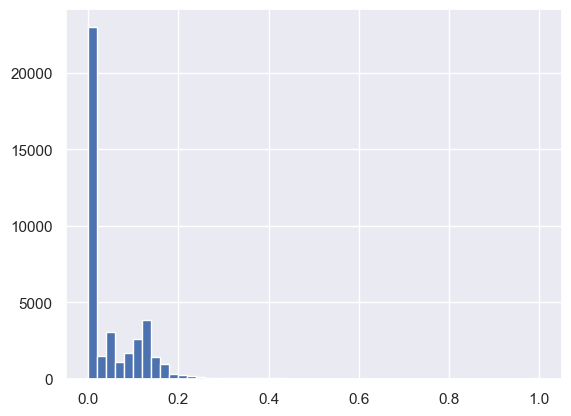

In [33]:
#plot a histogram of recovery_rate with bins=50
plt.hist(load_data_defaults['recovery_rate'],bins=50)
plt.show()

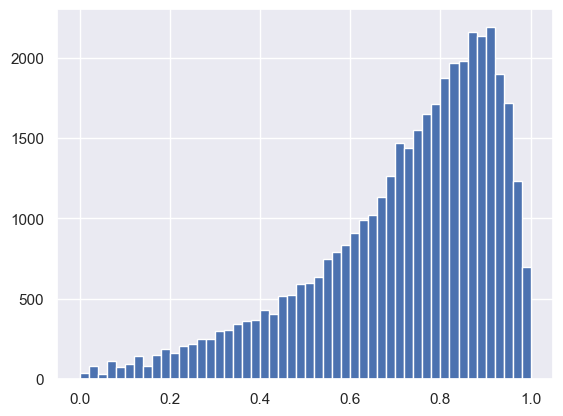

In [34]:
#plot a histogram of CCF with 50 bins
plt.hist(load_data_defaults['CCF'],bins=50)
plt.show()

In [35]:
#create a new column recovery_rate_0_1...if the recovery_rate is 0 then insert 0 and if it is greater than 0 replace it with 1
load_data_defaults['recovery_rate_0_1'] = np.where(load_data_defaults['recovery_rate'] == 0,0,1)

In [36]:
#value_counts of recovery_rate_0_1
load_data_defaults['recovery_rate_0_1'].value_counts()

recovery_rate_0_1
0    21276
1    19502
Name: count, dtype: int64

# LGD_Model

In LGD model we will basically create 2 models for determining the recovery rate if the recovery rate is 0 or greater than 0:

1.we will create a logistic regression model for determining whether the recovery rate is 0 or 1.

2.For all the recovery rate greater than 0 we will create a linear regression model to determine how much greater than 0 the value of recovery rate is.

#### Doing The First part: Stage_1

In [37]:
#check the column name of load_data_defaults
load_data_defaults.columns

Index(['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F',
       'grade:G', 'home_ownership:RENT_OTHER_NONE_ANY', 'home_ownership:OWN',
       'home_ownership:MORTGAGE',
       ...
       'mths_since_last_record:>=127', 'loan_amnt', 'funded_amnt', 'int_rate',
       'installment', 'recoveries', 'total_rec_prncp', 'recovery_rate', 'CCF',
       'recovery_rate_0_1'],
      dtype='object', length=153)

In [38]:
#Train Test split of load_data_defaults 
from sklearn.model_selection import train_test_split

lgd_input_train,lgd_input_test,lgd_target_train,lgd_target_test = train_test_split(load_data_defaults.drop(['recoveries','recovery_rate','recovery_rate_0_1','CCF'],axis=1),load_data_defaults['recovery_rate_0_1'],test_size=0.2,random_state=42)

In [39]:
#create a list of reference categories selecting only one column from each parent column
ref_categories=['grade:G',
               'home_ownership:RENT_OTHER_NONE_ANY',
               'addr_state:ND_NE_IA_NC_FL_HI_AL',
               'verification_status:Verified',
                'purpose:educ_sm_b_wedd_ren_en_mov_house',
                'initial_list_status:f',
                'term:60',
                'emp_length:0',
                'mths_since_issued_date:>165',
                'int_rate:20.281',
                'mths_since_earliest_cr_line:<140',
                'delinq_2yrs:>18',
                'inq_last_6mths:18',
                'open_acc:=0',
                'pub_rec:0-2',
                'total_acc:>85',
                'acc_now_delinq:=0',
                'total_rev_hi_lim:<=5k',
                'annual_inc:<20k',
                'dti:>40',
                'mths_since_last_delinq:0-3',
                'mths_since_last_record:Missing'
               ]

In [40]:
#drop the reference categories from lgd_input_train
lgd_input_train = lgd_input_train.drop(ref_categories,axis=1)

In [41]:
#import logistic regression and metrics
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [42]:
#create an object of logistic regression with max_iter=200
reg = LogisticRegression(max_iter=200)                                                         
#for prediction 0 or 1 via logistic and then how much by linear reg

In [47]:
#check the shape of lgd_input_train
lgd_input_train.shape

(32622, 127)

In [48]:
#check the shape of lgd_target_train
lgd_target_train.shape

(32622,)

In [49]:
#fit the logistic reg model on lgd_inputs_train and lgd_target_train
reg.fit(lgd_input_train,lgd_target_train)

LogisticRegression(max_iter=200)

In [ ]:
#testing

In [50]:
#check the shape of lgd_input_test
lgd_input_test.shape

(8156, 149)

In [51]:
#drop the reference categories from lgd_input_test
lgd_input_test = lgd_input_test.drop(ref_categories,axis=1)

In [52]:
#check the shape of lgd_input_test ---- make sure that the number of columns used in training is same as the number of columns in testing
lgd_input_test.shape

(8156, 127)

In [53]:
#predict the results of lgd_input_test
pred = reg.predict(lgd_input_test)

In [54]:
#predict the result using predict_proba function
prob_pred = reg.predict_proba(lgd_input_test)[:][:,1]

In [58]:
#create an empty dataframe that will store the final results
df_actual_predicted_probs = pd.DataFrame()

In [59]:
#create 2 columns one will store the pred and other will store the prob_pred
df_actual_predicted_probs['lgd_test_outcome'] =pred
df_actual_predicted_probs['lgd_test_proba'] = prob_pred

In [60]:
#check the head of the dataframe
df_actual_predicted_probs.head()

,lgd_test_outcome,lgd_test_proba
0,1,0.672206
1,1,0.542206
2,1,0.550882
3,1,0.755165
4,1,0.614200


In [ ]:
#You can also get 0 or 1 by defining a threshold value of prob_pred
#tr=0.5
#df_actual_predicted_probs['pred'] = np.where(df_actual_predicted_probs['lgd_test_proba'] > tr,1,0) 

In [61]:
#check the shape of df_actual_predicted_probs
df_actual_predicted_probs.shape

(8156, 2)

In [64]:
#print the confusion matrix using lgd_target_test and pred
metrics.confusion_matrix(lgd_target_test,pred)

array([[3057, 1174],
       [1213, 2712]])

In [65]:
a=metrics.f1_score(lgd_target_test,pred)
print(float(a))

0.694405325822558


In [66]:
#accuracy of model
b=metrics.accuracy_score(lgd_target_test,pred)
print(float(b))

0.7073320255026974


In [67]:
#import pickle
import pickle

In [68]:
#save the reg model
pickle.dump(reg,open('lgd_stage_1.sav','wb'))

stage-2...where >0 linear reg to determine how much >0   for recovery rate

Stage_2:Take those records where recovery_rate_0_1 is 1 and determine the recovery_rate by Linear REG

In [69]:
#take all records from load_data_defaults hwere recovery_rate_0_1 is 1
lgd_loan_data_2 = load_data_defaults[load_data_defaults['recovery_rate_0_1'] == 1]

In [70]:
#check the shape of lgd_loan_data_2
lgd_loan_data_2.shape

(19502, 153)

In [71]:
#train test split
lgd_input_train_2,lgd_input_test_2,lgd_target_train_2,lgd_target_test_2 = train_test_split(lgd_loan_data_2.drop(['recoveries','recovery_rate','recovery_rate_0_1','CCF'],axis=1),lgd_loan_data_2['recovery_rate'],test_size=0.2,random_state=42)

In [72]:
#drop the refrence categories from lgd_input_train_2
lgd_input_train_2 = lgd_input_train_2.drop(ref_categories,axis=1)

In [73]:
#import linear regression
from sklearn.linear_model import LinearRegression

In [74]:
#create an object  of linear regression
lin_reg =LinearRegression()

In [75]:
#fit the lin_reg on lgd_input_train_2,lgd_target_train_2
lin_reg.fit(lgd_input_train_2,lgd_target_train_2)

LinearRegression()

In [76]:
#drop the refrence categories from lgd_input_test
lgd_input_test_2 = lgd_input_test_2.drop(ref_categories,axis=1)

In [77]:
#check the shape of lgd_input_test_2...make sure the number of columns are same as that of lgd_input_train_2
lgd_input_test_2.shape

(3901, 127)

In [78]:
#predict the results
pred_lin = lin_reg.predict(lgd_input_test_2)

In [79]:
#print the predicted results
pred_lin

array([0.12336847, 0.07010877, 0.1131982 , ..., 0.11994648, 0.06410679,
       0.08125609])

In [80]:
#check the r2_score
metrics.r2_score(lgd_target_test_2,pred_lin)

0.12612811488542885

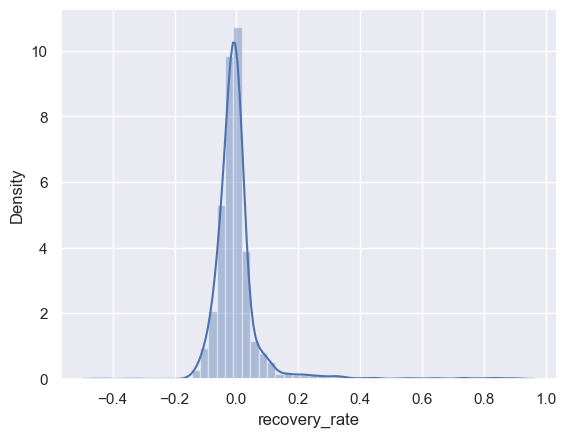

In [81]:
#plot the distribution plot for lgd_target_test_2-pred_lin
sns.distplot(lgd_target_test_2-pred_lin)

plt.show()

In [82]:
#save the model using pickle
pickle.dump(lin_reg,open('lgd_stage_2.sav','wb'))

# combination of stage1 and stage2

we will multiply the results of stage_1 and stage_2

In [83]:
#using the ln_reg method predict the results of stage_1 test i.e lgd_input_test
pred_stage_2_all = lin_reg.predict(lgd_input_test)

In [84]:
#print the pred_stage_2_all
pred_stage_2_all

array([0.08085596, 0.04832052, 0.15816785, ..., 0.06684058, 0.11183373,
       0.15503301])

In [85]:
#make sure that the length of pred and pred_stage_2_all is same becoz we will combine the results by multiplying them
print(len(pred),len(pred_stage_2_all))

8156 8156


In [86]:
#multiply the stage_1 and stage_2 results
pred_lgd_final = pred*pred_stage_2_all

In [87]:
#print the pred_lgd_final
pred_lgd_final

array([0.08085596, 0.04832052, 0.15816785, ..., 0.06684058, 0.11183373,
       0.        ])

In [88]:
#check the basic stats of pred_lgd_final
pd.DataFrame(pred_lgd_final).describe()

,0
count,8156.000000
mean,0.048744
std,0.055795
min,0.000000
25%,0.000000
50%,0.000000
75%,0.097880
max,0.422916


# EAD MODEL

In [89]:
#check the columns of load_data_defaults
load_data_defaults.columns

Index(['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F',
       'grade:G', 'home_ownership:RENT_OTHER_NONE_ANY', 'home_ownership:OWN',
       'home_ownership:MORTGAGE',
       ...
       'mths_since_last_record:>=127', 'loan_amnt', 'funded_amnt', 'int_rate',
       'installment', 'recoveries', 'total_rec_prncp', 'recovery_rate', 'CCF',
       'recovery_rate_0_1'],
      dtype='object', length=153)

In [90]:
#Train test split using the CCF as output feature
ead_inputs_train, ead_inputs_test, ead_targets_train, ead_targets_test = train_test_split(load_data_defaults.drop(['recoveries','recovery_rate','recovery_rate_0_1','CCF'],axis=1),load_data_defaults['CCF'],test_size=0.2,random_state=42) 

In [91]:
#drop the refrence categories
ead_inputs_train =ead_inputs_train.drop(ref_categories,axis=1)

In [92]:
#create an object of linear regression and fit it on ead_inputs_train,ead_targets_train
reg_ead =LinearRegression()
reg_ead.fit(ead_inputs_train,ead_targets_train)

LinearRegression()

In [93]:
#drop the refrence categories from ead_inputs_test
ead_inputs_test = ead_inputs_test.drop(ref_categories,axis=1)

In [94]:
#predict the results of ead_inputs_test
y_pred_test_ead = reg_ead.predict(ead_inputs_test)

In [95]:
#print the results
y_pred_test_ead

array([0.57067836, 0.37911304, 0.89341298, ..., 0.67561318, 0.90292041,
       0.90413808])

<Axes: xlabel='CCF', ylabel='Density'>

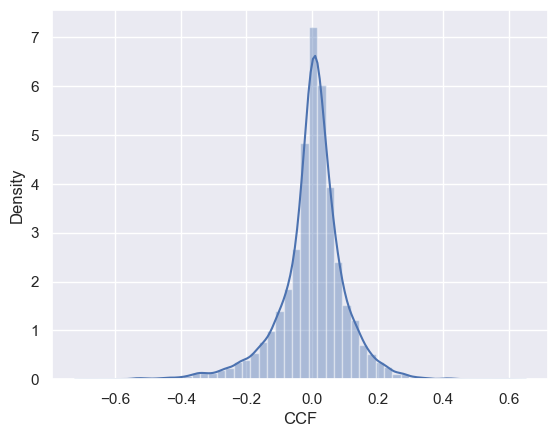

In [96]:
#plot the distribution plot of ead_targets_test-y_pred_test_ead
sns.distplot(ead_targets_test-y_pred_test_ead)

In [97]:
#chekc the basic stats of y_pred_test_ead
pd.DataFrame(y_pred_test_ead).describe()

,0
count,8156.000000
mean,0.720180
std,0.174365
min,-0.586324
25%,0.634257
50%,0.730882
75%,0.832180
max,1.292372


We see that some values are negative and this predicted value is of CCF...so it can't be negative

In [98]:
#replace all the negitive values with 0 and all values which are greater than 1 with 1
y_pred_test_ead = np.where(y_pred_test_ead < 0,0,y_pred_test_ead)
y_pred_test_ead = np.where(y_pred_test_ead > 1,1,y_pred_test_ead)

In [99]:
#save the EAD model
pickle.dump(reg_ead,open('ead_model.sav','wb'))

In [100]:
#now again check the basic stats of y_pred_test_ead
pd.DataFrame(y_pred_test_ead).describe()

,0
count,8156.000000
mean,0.718811
std,0.166870
min,0.000000
25%,0.634257
50%,0.730882
75%,0.832180
max,1.000000


# Calculating EL:

### Expected Loss = PD * LGD * EAD

In [101]:
#check the shape of lgd_input_test
lgd_input_test.shape

(8156, 127)

In [102]:
#check the shape of lgd_target_test
lgd_target_test.shape

(8156,)

In [103]:
#Take a testing sample as lgd_input_test and predict the EXPECTED LOSS
testing_sample = lgd_input_test

In [104]:
#check the shape of testing_sample
testing_sample.shape

(8156, 127)

In [105]:
#create an empty dataframe that will store the final results
testing_outcome = pd.DataFrame()

In [106]:
#create 2 columns for prediction of LGD_stage_1 and LGD_stage_2
testing_outcome['recovery_rate_stage_1'] = reg.predict(testing_sample)
testing_outcome['recovery_rate_stage_2'] = lin_reg.predict(testing_sample)

In [107]:
#create a new column recovery_rate that will have the fianl results of LGD_Model i.e the combition of stage_1 and stage_2
testing_outcome['recovery_rate'] = testing_outcome['recovery_rate_stage_1']*testing_outcome['recovery_rate_stage_2'] 

In [108]:
#check the head of testing_outcome
testing_outcome.head()

,recovery_rate_stage_1,recovery_rate_stage_2,recovery_rate
0,1,0.080856,0.080856
1,1,0.048321,0.048321
2,1,0.158168,0.158168
3,1,0.054424,0.054424
4,1,0.078967,0.078967


In [109]:
#replace all the negative values in recovery_rate with 0 and all values which are greater than 1 with 1
testing_outcome['recovery_rate'] =np.where(testing_outcome['recovery_rate']<0,0,testing_outcome['recovery_rate'])
testing_outcome['recovery_rate'] =np.where(testing_outcome['recovery_rate']>1,1,testing_outcome['recovery_rate'])

In [110]:
#create a new column LGD in testing_outcome i.e (1-recovery_rate)
testing_outcome['LGD'] = 1-testing_outcome['recovery_rate']
testing_outcome.head()

,recovery_rate_stage_1,recovery_rate_stage_2,recovery_rate,LGD
0,1,0.080856,0.080856,0.919144
1,1,0.048321,0.048321,0.951679
2,1,0.158168,0.158168,0.841832
3,1,0.054424,0.054424,0.945576
4,1,0.078967,0.078967,0.921033


In [111]:
#check the basic stats of LGD
testing_outcome['LGD'].describe()

count    8156.000000
mean        0.951256
std         0.055795
min         0.577084
25%         0.902120
50%         1.000000
75%         1.000000
max         1.000000
Name: LGD, dtype: float64

In [112]:
#create a new column CCF that will store the predicted results of EAD_Model
testing_outcome['CCF'] = reg_ead.predict(testing_sample)

In [113]:
#check the basic stats of CCF
testing_outcome['CCF'].describe()

count    8156.000000
mean        0.720180
std         0.174365
min        -0.586324
25%         0.634257
50%         0.730882
75%         0.832180
max         1.292372
Name: CCF, dtype: float64

In [114]:
#replace all the negative values in CCF with 0 and all values which are greater than 1 with 1
testing_outcome['CCF'] =np.where(testing_outcome['CCF']<0,0,testing_outcome['CCF'])
testing_outcome['CCF'] =np.where(testing_outcome['CCF']>1,1,testing_outcome['CCF'])

In [115]:
#check the basic stats of CCF
testing_outcome['CCF'].describe()

count    8156.000000
mean        0.718811
std         0.166870
min         0.000000
25%         0.634257
50%         0.730882
75%         0.832180
max         1.000000
Name: CCF, dtype: float64

In [116]:
#check the shape of testing_outcome
testing_outcome.shape

(8156, 5)

In [117]:
#check the shape of testing_sample
testing_sample.shape

(8156, 127)

In [118]:
#create a new column EAD i.e (CCF * funded_amt)
testing_outcome['EAD'] = testing_outcome['CCF'] * testing_sample['funded_amnt'].values

In [119]:
#check the head of testing_outcome
testing_outcome.head()

,recovery_rate_stage_1,recovery_rate_stage_2,recovery_rate,LGD,CCF,EAD
0,1,0.080856,0.080856,0.919144,0.570678,8560.175401
1,1,0.048321,0.048321,0.951679,0.379113,4549.356424
2,1,0.158168,0.158168,0.841832,0.893413,15478.379935
3,1,0.054424,0.054424,0.945576,0.518232,2591.158414
4,1,0.078967,0.078967,0.921033,0.608340,4638.589515


In [120]:
#check the basic stats of EAD
testing_outcome['EAD'].describe()

count     8156.000000
mean     10725.094843
std       7522.111754
min          0.000000
25%       5027.971737
50%       8694.003104
75%      14504.626470
max      35000.000000
Name: EAD, dtype: float64

## Calculate results of PD_Model

In [121]:
#check the columns of testing_sample
testing_sample.columns

Index(['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F',
       'home_ownership:OWN', 'home_ownership:MORTGAGE', 'addr_state:NM_VA',
       'addr_state:OK_TN_MO_LA_MD_NC',
       ...
       'mths_since_last_delinq:>=57', 'mths_since_last_record:0-90',
       'mths_since_last_record:90-120', 'mths_since_last_record:120-127',
       'mths_since_last_record:>=127', 'loan_amnt', 'funded_amnt', 'int_rate',
       'installment', 'total_rec_prncp'],
      dtype='object', length=127)

### Make sure you pass only those columns to the PD_Model which you have passed in PD_Model while model training

In [122]:
#Drop total_rec_prncp column as we didn't pass this in PD_Model while model training
testing_sample.drop('total_rec_prncp',axis=1,inplace=True)

In [124]:
#load the PD_model which we have created Earlier
reg_pd = pickle.load(open('pd_model_gradient.sav','rb'))

In [125]:
#predict the results of testing_sample using the PD_model
reg_pd.predict_proba(testing_sample)[:][:,0]

array([0.25445204, 0.17761117, 0.22739082, ..., 0.24519046, 0.20970192,
       0.11842137])

In [127]:
#predict the predict_proba results of testing_sample using PD_Model and store it in 'PD'
testing_outcome['PD'] = reg_pd.predict_proba(testing_sample)[:][:,0]

In [128]:
#check the hed of testing_outcome
testing_outcome.head()

,recovery_rate_stage_1,recovery_rate_stage_2,recovery_rate,LGD,CCF,EAD,PD
0,1,0.080856,0.080856,0.919144,0.570678,8560.175401,0.254452
1,1,0.048321,0.048321,0.951679,0.379113,4549.356424,0.177611
2,1,0.158168,0.158168,0.841832,0.893413,15478.379935,0.227391
3,1,0.054424,0.054424,0.945576,0.518232,2591.158414,0.151592
4,1,0.078967,0.078967,0.921033,0.608340,4638.589515,0.198821


In [129]:
#check the basic stats of PD
testing_outcome['PD'].describe()

count    8156.000000
mean        0.147217
std         0.069448
min         0.015972
25%         0.095124
50%         0.136415
75%         0.188633
max         0.445330
Name: PD, dtype: float64

In [130]:
#create a new column 'EL' i.e Expected_Loss by ('PD' * 'LGD' * 'EAD')
testing_outcome['EL'] = testing_outcome['PD']*testing_outcome['LGD']*testing_outcome['EAD']

In [131]:
#check the head of testing_outcome
testing_outcome.head()

,recovery_rate_stage_1,recovery_rate_stage_2,recovery_rate,LGD,CCF,EAD,PD,EL
0,1,0.080856,0.080856,0.919144,0.570678,8560.175401,0.254452,2002.037347
1,1,0.048321,0.048321,0.951679,0.379113,4549.356424,0.177611,768.972743
2,1,0.158168,0.158168,0.841832,0.893413,15478.379935,0.227391,2962.947423
3,1,0.054424,0.054424,0.945576,0.518232,2591.158414,0.151592,371.422222
4,1,0.078967,0.078967,0.921033,0.608340,4638.589515,0.198821,849.422257


In [132]:
#Add the column 'funded_amnt' from testing_sample to testing_outcome
testing_outcome['Funded_amt'] = testing_sample['funded_amnt'].values

In [133]:
#check the head of testing_outcome
testing_outcome.head()

,recovery_rate_stage_1,recovery_rate_stage_2,recovery_rate,LGD,CCF,EAD,PD,EL,Funded_amt
0,1,0.080856,0.080856,0.919144,0.570678,8560.175401,0.254452,2002.037347,15000
1,1,0.048321,0.048321,0.951679,0.379113,4549.356424,0.177611,768.972743,12000
2,1,0.158168,0.158168,0.841832,0.893413,15478.379935,0.227391,2962.947423,17325
3,1,0.054424,0.054424,0.945576,0.518232,2591.158414,0.151592,371.422222,5000
4,1,0.078967,0.078967,0.921033,0.608340,4638.589515,0.198821,849.422257,7625


In [134]:
#Finally, create a new_dataframe testing_outcome_final which will have only 'Funded_amt','PD','LGD','EAD','EL'
testing_outcome_final = testing_outcome[['Funded_amt','PD','LGD','EAD','EL']]
testing_outcome_final.head()

,Funded_amt,PD,LGD,EAD,EL
0,15000,0.254452,0.919144,8560.175401,2002.037347
1,12000,0.177611,0.951679,4549.356424,768.972743
2,17325,0.227391,0.841832,15478.379935,2962.947423
3,5000,0.151592,0.945576,2591.158414,371.422222
4,7625,0.198821,0.921033,4638.589515,849.422257


record:0---When the Funded amount is 15000 the bank suffers a loss of 2002.03 from that customer..

record:1---When the Funded amount is 12000 the bank suffers a loss of 768.97 from that customer..

record:3---When the Funded amount is 17325 the bank suffers a loss of 2962.94 from that customer..


and so on......



## We will get the overall expected_loss suffered by the bank

In [136]:
#Divide the  expected_loss sum by funded_amnt sum
el=testing_outcome_final['EL'].sum()/testing_outcome_final['Funded_amt'].sum()
print(float(el))

0.10605394749304839


We observe that the Bank suffers an Expected loss of 10.6% while giving loans to it's customers

#observed EL is between 2% to 15% based on this banks can be aggressive or lenient while giving loans

Thank you!!!!